In [ ]:
from google.colab import files

uploaded = files.upload()

Saving df_eda (4).csv to df_eda (4) (2).csv


# **Análisis Exploratorio Violencia contra la mujer**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Agrupar tipos de violencia sexual
tipos_sexual = [
    'ACTOS SEXUALES', 'ACCESO CARNAL', 'OTRAS VIOLENCIAS SEXUALES',
    'ACOSO SEXUAL', 'ABUSO SEXUAL', 'EXPLOTACIÓN SEXUAL',
    'TRATA DE PERSONAS', 'MUTILACIÓN GENITAL'
]


In [ ]:
df_raw= pd.read_csv('df_eda (13).csv', sep=',')

In [ ]:
df_raw

,id_paciente,nacionali_,edad_anios,grupo_etario,nombre_nacionalidad,sexo_,fec_con_,anio_con,mes_con,dia_con,...,ident_gene_txt,consum_spa,persona_con_jefatura_de_hogar,antec,presencia_de_alcohol_u_otra_sustancia_en_la_vctima,sexo_agre,relacion_agresor,conv_agre,zona_conf,escenario_txt
0,19850,170,20.0,JUVENTUD (19 – 27),COLOMBIA,F,2020-01-01,2020.0,1.0,1.0,...,FEMENINO,0.0,0.0,0.0,1.0,M,AMIGO(A),0.0,0.0,VIVIENDA
1,352298,170,38.0,ADULTEZ (28 – 59),COLOMBIA,F,2020-01-01,2020.0,1.0,1.0,...,FEMENINO,0.0,1.0,0.0,0.0,M,FAMILIAR,1.0,0.0,VIVIENDA
2,363378,170,36.0,ADULTEZ (28 – 59),COLOMBIA,F,2020-01-01,2020.0,1.0,1.0,...,FEMENINO,0.0,0.0,0.0,0.0,M,PAREJA,1.0,0.0,VIVIENDA
3,457991,170,6.0,INFANCIA (6 – 11),COLOMBIA,F,2020-01-01,2020.0,1.0,1.0,...,FEMENINO,0.0,0.0,0.0,0.0,M,FAMILIAR,1.0,0.0,VIVIENDA
4,22520,170,31.0,ADULTEZ (28 – 59),COLOMBIA,F,2020-01-01,2020.0,1.0,1.0,...,FEMENINO,0.0,0.0,1.0,0.0,M,PAREJA,1.0,0.0,VIVIENDA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198758,85996,170,33.0,ADULTEZ (28 – 59),COLOMBIA,F,2025-11-15,2025.0,11.0,15.0,...,FEMENINO,0.0,1.0,1.0,0.0,M,EXPAREJA,0.0,0.0,VIVIENDA
198759,206141,170,49.0,ADULTEZ (28 – 59),COLOMBIA,F,2025-12-31,2025.0,12.0,31.0,...,FEMENINO,0.0,1.0,1.0,0.0,M,PAREJA,1.0,0.0,VIVIENDA
198760,481555,170,14.0,ADOLESCENCIA (12 – 18),COLOMBIA,F,2025-12-19,2025.0,12.0,19.0,...,FEMENINO,0.0,1.0,1.0,0.0,M,PAREJA,0.0,0.0,VIVIENDA
198761,343000,170,47.0,ADULTEZ (28 – 59),COLOMBIA,F,2025-12-06,2025.0,12.0,6.0,...,FEMENINO,0.0,1.0,0.0,0.0,M,JEFE,0.0,0.0,LUGAR DE TRABAJO


In [ ]:
df_raw['tipo_agrupado'] = df_raw['tipo_violencia_txt'].apply(
    lambda x: 'VIOLENCIA SEXUAL' if x in tipos_sexual
    else ('VIOLENCIA FÍSICA' if x == 'VIOLENCIA FÍSICA' else 'OTRO')
)

# Filtrar solo mujeres + física/sexual
df = df_raw[
    (df_raw['sexo_'] == 'F') &
    (df_raw['tipo_agrupado'].isin(['VIOLENCIA FÍSICA', 'VIOLENCIA SEXUAL']))
].copy()

df['anio_con'] = df['anio_con'].astype(int)

print(f"Registros filtrados: {len(df):,}")
print(df['tipo_agrupado'].value_counts())

Registros filtrados: 110,086
tipo_agrupado
VIOLENCIA SEXUAL    62445
VIOLENCIA FÍSICA    47641
Name: count, dtype: int64


GRÁFICA 1: Evolución anual de casos por tipo de violencia

In [ ]:
import itertools

COLORES = ['#1f77b4', '#ff7f0e', '#2ca02c']
ciclo = itertools.cycle(colores)

for col in evol.columns:
    ax.plot(evol.index, evol[col],
            marker='o', linewidth=2.5,
            color=next(ciclo),
            label=col.title())

In [ ]:
COLORES = {
    'ambos': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
}

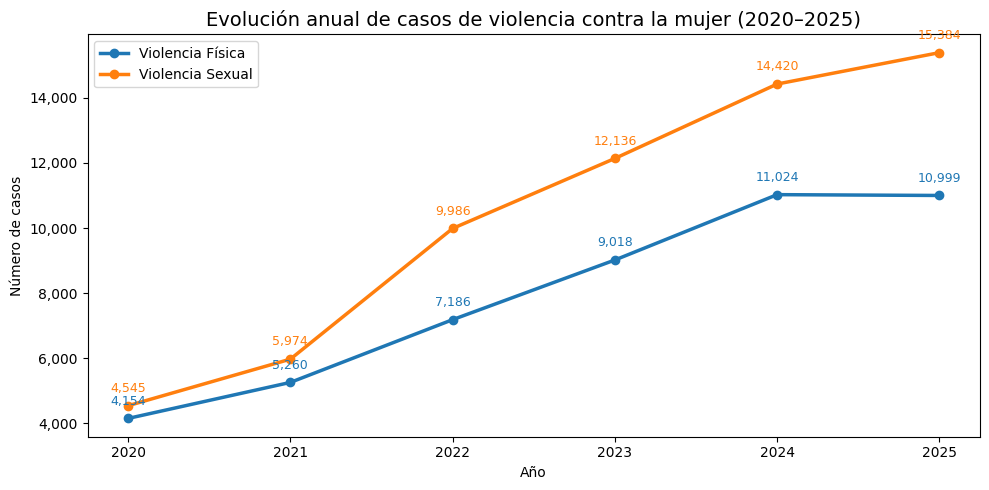

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

evol = df.groupby(['anio_con', 'tipo_agrupado']).size().unstack()

for col, color in zip(evol.columns, COLORES['ambos']):
    ax.plot(evol.index, evol[col], marker='o', linewidth=2.5,
            color=color, label=col.title())
    for x, y in zip(evol.index, evol[col]):
        ax.annotate(f'{y:,}', (x, y), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9, color=color)

ax.set_title('Evolución anual de casos de violencia contra la mujer (2020–2025)', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('Número de casos')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('g1_evolucion_anual.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# GRÁFICA 2: Distribución por grupo etario y tipo de violencia

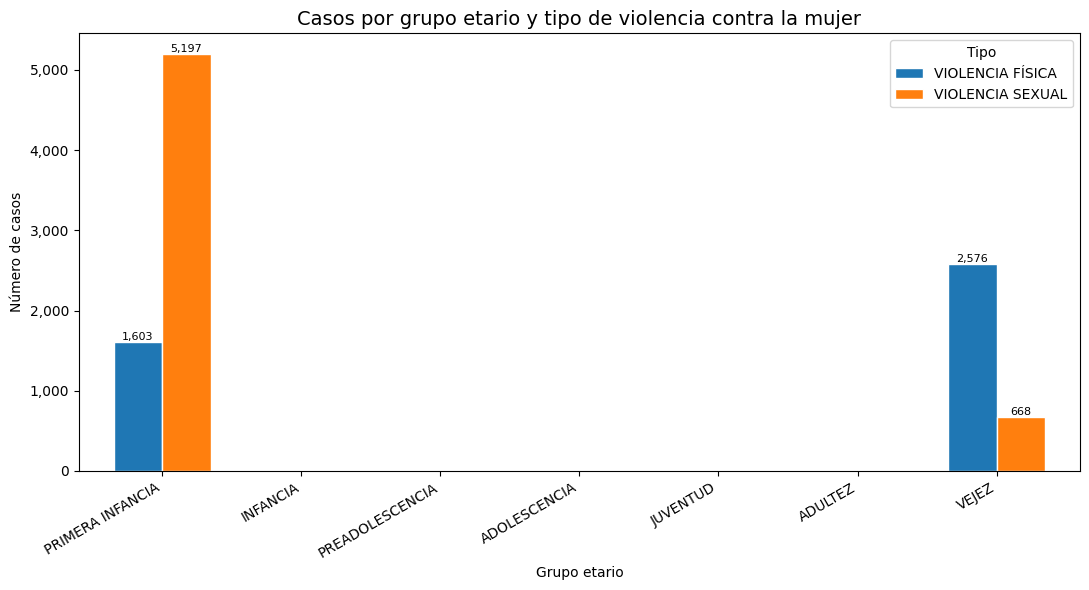

In [ ]:
orden_etario = [
    'PRIMERA INFANCIA (0 –  5) ', 'INFANCIA (6 – 9)',
    'PREADOLESCENCIA (10 – 14) ', 'ADOLESCENCIA (15 – 18)',
    'JUVENTUD (19 – 29)', 'ADULTEZ (30 – 59)', 'VEJEZ (60 +)'
]

etario = df.groupby(['grupo_etario', 'tipo_agrupado']).size().unstack().reindex(orden_etario)

fig, ax = plt.subplots(figsize=(11, 6))
etario.plot(kind='bar', ax=ax, color=COLORES['ambos'], edgecolor='white', width=0.7)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

ax.set_title('Casos por grupo etario y tipo de violencia contra la mujer', fontsize=14)
ax.set_xlabel('Grupo etario')
ax.set_ylabel('Número de casos')
ax.set_xticklabels([e.split('(')[0].strip() for e in orden_etario], rotation=30, ha='right')
ax.legend(title='Tipo')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('g2_grupo_etario.png', dpi=150, bbox_inches='tight')
plt.show()


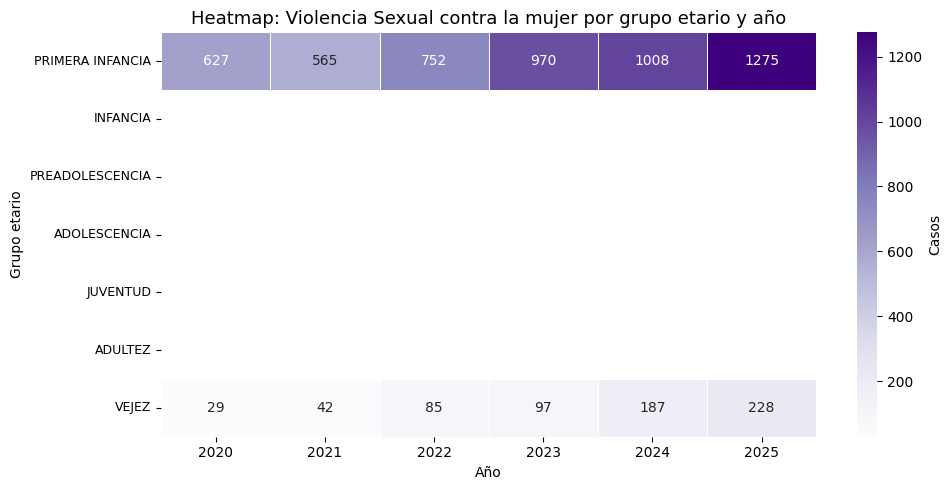

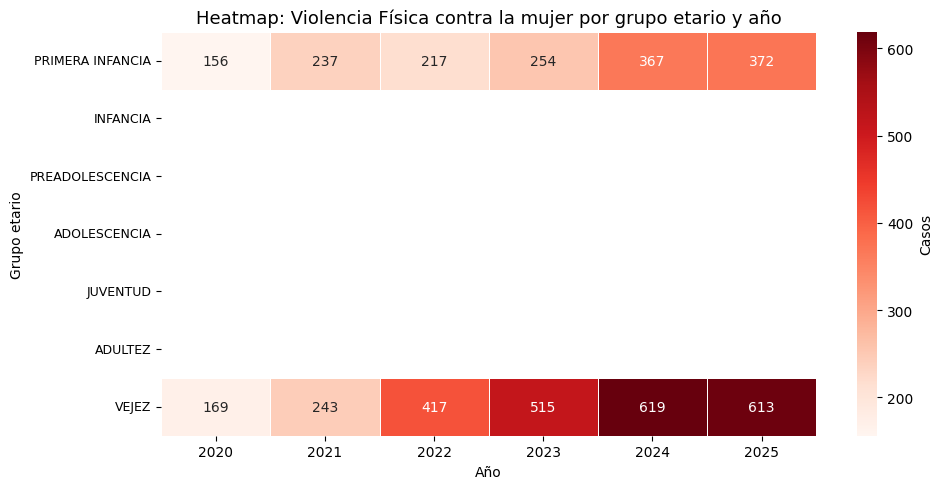

In [ ]:
for tipo, color_map, titulo in [
    ('VIOLENCIA SEXUAL',  'Purples', 'Violencia Sexual'),
    ('VIOLENCIA FÍSICA',  'Reds',    'Violencia Física')
]:
    sub = df[df['tipo_agrupado'] == tipo]
    heat = sub.groupby(['grupo_etario', 'anio_con']).size().unstack().reindex(orden_etario)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(heat, annot=True, fmt='.0f', cmap=color_map,
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Casos'})
    ax.set_title(f'Heatmap: {titulo} contra la mujer por grupo etario y año', fontsize=13)
    ax.set_xlabel('Año')
    ax.set_ylabel('Grupo etario')
    ax.set_yticklabels([e.split('(')[0].strip() for e in orden_etario],
                       rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig(f'g3_heatmap_{tipo.split()[1].lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, tipo, color in zip(axes,
    ['VIOLENCIA FÍSICA', 'VIOLENCIA SEXUAL'],
    COLORES['ambos']):

    sub = df[df['tipo_agrupado'] == tipo]
    rel = sub['relacion_agresor'].value_counts().head(10)

    bars = ax.barh(rel.index[::-1], rel.values[::-1], color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, rel.values[::-1]):
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)

    ax.set_title(f'Relación con el agresor\n{tipo.title()}', fontsize=12)
    ax.set_xlabel('Número de casos')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Top 10 relaciones con el agresor — Violencia contra la mujer', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('g4_relacion_agresor.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, tipo, color in zip(axes,
    ['VIOLENCIA FÍSICA', 'VIOLENCIA SEXUAL'],
    COLORES['ambos']):

    sub = df[df['tipo_agrupado'] == tipo]
    esc = sub['escenario_txt'].value_counts().head(8)
    total = esc.sum()
    pcts = (esc / total * 100).round(1)

    wedges, texts, autotexts = ax.pie(
        esc.values, labels=None, autopct='%1.1f%%',
        colors=sns.color_palette('Set2', len(esc)),
        startangle=140, pctdistance=0.75,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for at in autotexts:
        at.set_fontsize(8)

    ax.legend(wedges, esc.index, loc='lower center',
              bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=8)
    ax.set_title(f'Escenario de ocurrencia\n{tipo.title()}', fontsize=12)

plt.suptitle('Escenario de violencia contra la mujer', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('g5_escenario.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
spa_map = {0: 'Sin SPA', 1: 'Con SPA'}
df['spa_label'] = df['presencia_de_alcohol_u_otra_sustancia_en_la_vctima'].map(spa_map)

spa = df.groupby(['anio_con', 'tipo_agrupado', 'spa_label']).size().reset_index(name='casos')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, tipo, color in zip(axes,
    ['VIOLENCIA FÍSICA', 'VIOLENCIA SEXUAL'],
    COLORES['ambos']):

    sub = spa[spa['tipo_agrupado'] == tipo].pivot(
        index='anio_con', columns='spa_label', values='casos').fillna(0)

    sub.plot(kind='bar', ax=ax, color=['#2ECC71', color], edgecolor='white', width=0.7)
    ax.set_title(f'Presencia de SPA en víctima\n{tipo.title()}', fontsize=12)
    ax.set_xlabel('Año')
    ax.set_ylabel('Casos')
    ax.set_xticklabels(sub.index, rotation=0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(title='SPA')

plt.suptitle('Presencia de alcohol/sustancias en la víctima por año y tipo', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('g6_spa.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, tipo, color in zip(axes,
    ['VIOLENCIA FÍSICA', 'VIOLENCIA SEXUAL'],
    COLORES['ambos']):

    sub = df[df['tipo_agrupado'] == tipo]
    etnia = sub['per_etn_nom'].value_counts().head(7)

    bars = ax.bar(etnia.index, etnia.values, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{int(bar.get_height()):,}', ha='center', fontsize=8)

    ax.set_title(f'Pertenencia étnica — {tipo.title()}', fontsize=12)
    ax.set_xlabel('Etnia')
    ax.set_ylabel('Casos')
    ax.set_xticklabels(etnia.index, rotation=30, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribución étnica de víctimas de violencia', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('g7_etnia.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, tipo, color in zip(axes,
    ['VIOLENCIA FÍSICA', 'VIOLENCIA SEXUAL'],
    COLORES['ambos']):

    sub = df[df['tipo_agrupado'] == tipo]
    ss = sub['tip_ss_nom'].value_counts()

    wedges, _, autotexts = ax.pie(
        ss.values, labels=None, autopct='%1.1f%%',
        colors=sns.color_palette('pastel', len(ss)),
        startangle=140, pctdistance=0.78,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for at in autotexts:
        at.set_fontsize(9)
    ax.legend(wedges, ss.index, loc='lower center',
              bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=8)
    ax.set_title(f'Tipo de afiliación en salud\n{tipo.title()}', fontsize=12)

plt.suptitle('Seguridad social de las víctimas de violencia', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('g8_seguridad_social.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
meses_orden = ['ENERO','FEBRERO','MARZO','ABRIL','MAYO','JUNIO',
               'JULIO','AGOSTO','SEPTIEMBRE','OCTUBRE','NOVIEMBRE','DICIEMBRE']

fig, ax = plt.subplots(figsize=(12, 5))

for tipo, color in zip(['VIOLENCIA FÍSICA', 'VIOLENCIA SEXUAL'], COLORES['ambos']):
    sub = df[df['tipo_agrupado'] == tipo]
    mes_cnt = sub['mes_nombre'].str.upper().value_counts().reindex(meses_orden, fill_value=0)
    ax.plot(meses_orden, mes_cnt.values, marker='o', linewidth=2.5,
            color=color, label=tipo.title())

ax.set_title('Estacionalidad mensual de la violencia contra la mujer (acumulado 2020–2025)', fontsize=13)
ax.set_xlabel('Mes')
ax.set_ylabel('Casos')
ax.set_xticklabels(meses_orden, rotation=45, ha='right')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('g9_estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
df['estrato_clean'] = pd.to_numeric(df['estrato_'], errors='coerce')
df_est = df[df['estrato_clean'].between(1, 6)]

fig, ax = plt.subplots(figsize=(10, 5))

est = df_est.groupby(['estrato_clean', 'tipo_agrupado']).size().unstack()
est.plot(kind='bar', ax=ax, color=COLORES['ambos'], edgecolor='white', width=0.7)

ax.set_title('Casos por estrato socioeconómico y tipo de violencia contra la mujer', fontsize=13)
ax.set_xlabel('Estrato')
ax.set_ylabel('Número de casos')
ax.set_xticklabels([f'Estrato {int(e)}' for e in est.index], rotation=0)
ax.legend(title='Tipo')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('g10_estrato.png', dpi=150, bbox_inches='tight')
plt.show()

